[*********************100%***********************]  5 of 5 completed


⚠ Historical stress window not found. Using worst rolling volatility window instead.

===== Portfolio Risk Measures =====
VaR (99%):                  $17,416.91
Expected Shortfall (99%):   $20,395.61
Stressed VaR (99%):         $30,421.25


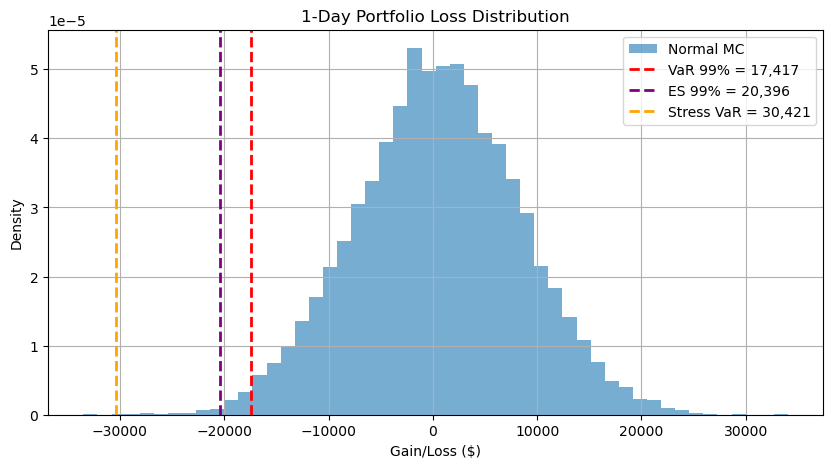

In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt

years = 10
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days=365 * years)

tickers = ['SPY', 'BND', 'GLD', 'QQQ', 'VTI']

prices = yf.download(tickers, start=startDate, end=endDate, auto_adjust=True)['Close']

log_returns = np.log(prices / prices.shift(1)).dropna()

portfolio_value = 1_000_000
weights = np.ones(len(tickers)) / len(tickers)

mu = log_returns.mean().values
cov = log_returns.cov().values

portfolio_mu = weights @ mu
portfolio_sigma = np.sqrt(weights @ cov @ weights)

simulations = 10_000
days = 1

z = np.random.normal(0, 1, simulations)

scenario_returns = portfolio_value * (
    portfolio_mu * days + portfolio_sigma * z * np.sqrt(days)
)

alpha = 0.99
percentile = (1 - alpha) * 100

VaR = -np.percentile(scenario_returns, percentile)
ES = -scenario_returns[scenario_returns <= np.percentile(scenario_returns, percentile)].mean()

stress_start = "2007-01-01"
stress_end = "2009-12-31"
stress_data = log_returns.loc[stress_start:stress_end]

if len(stress_data) < 50:
    print("⚠ Historical stress window not found. Using worst rolling volatility window instead.")

    rolling_vol = (
        log_returns.rolling(252).cov().dropna()
    )  
    
    pv = []
    dates = rolling_vol.index.get_level_values(0).unique()

    for date in dates:  
        Sigma = rolling_vol.loc[date].values
        pv.append((date, np.sqrt(weights @ Sigma @ weights)))

    vol_df = pd.DataFrame(pv, columns=["date", "pvol"]).set_index("date")

    worst_date = vol_df["pvol"].idxmax()

    stress_data = log_returns.loc[worst_date - pd.Timedelta(days=400): worst_date]

stress_cov = stress_data.cov().values
stress_sigma = np.sqrt(weights @ stress_cov @ weights)

stress_returns = portfolio_value * (
    portfolio_mu * days + stress_sigma * z * np.sqrt(days)
)

Stressed_VaR = -np.percentile(stress_returns, percentile)

print("\n===== Portfolio Risk Measures =====")
print(f"VaR (99%):                  ${VaR:,.2f}")
print(f"Expected Shortfall (99%):   ${ES:,.2f}")
print(f"Stressed VaR (99%):         ${Stressed_VaR:,.2f}")
print("===================================")

plt.figure(figsize=(10,5))
plt.hist(scenario_returns, bins=50, density=True, alpha=0.6, label="Normal MC")

plt.axvline(-VaR, color='red', linestyle='--', linewidth=2, label=f"VaR 99% = {VaR:,.0f}")
plt.axvline(-ES, color='purple', linestyle='--', linewidth=2, label=f"ES 99% = {ES:,.0f}")
plt.axvline(-Stressed_VaR, color='orange', linestyle='--', linewidth=2, label=f"Stress VaR = {Stressed_VaR:,.0f}")

plt.title("1-Day Portfolio Loss Distribution")
plt.xlabel("Gain/Loss ($)")
plt.ylabel("Density")
plt.grid(True)
plt.legend()
plt.show()